In [1]:
import jax 
import jax.numpy as jnp

import matplotlib.pyplot as plt
import seaborn as sns

from scoresbibm.src.tasks import HHTask
from scoresbibm.src.utils import load_model,query
from scoresbibm.src.utils.plot import use_style

from sbi.analysis import pairplot, marginal_plot
import numpy as np

In [2]:
df = query("bm_hh2")
df

,method,task,num_simulations,seed,model_id,metric,value,time_train,time_eval,cfg
0,score_transformer,hh,100000,0,0,c2st_joint,0.736125,1829.753555,12.679634,"{'name': 'bm_hh2', 'seed': 0, 'save_model': Tr..."
1,score_transformer,hh,100000,0,1,c2st_joint,0.725625,2183.045006,14.761006,"{'name': 'bm_hh2', 'seed': 0, 'save_model': Tr..."


In [3]:
limits = ((1.,2.), (60,120), (10,30), (0.1,0.5), (40,70),(-100, -60),(-90,-60))
labels = [r"$C_m$", r"$g_{Na}$", r"$g_K$", r"$g_L$", r"$E_{Na}$", r"$E_K$", r"$E_L$"]

In [4]:
task = HHTask()

simulator = task.get_simulator()
dataset = task.get_data(100, rng=jax.random.PRNGKey(0))

In [5]:
x_o = dataset["x"][1,:7]
energy_true = dataset["x"][1,7:]
theta_true = dataset["theta"][1]

In [6]:
x_o

Array([ 12.   , -68.613,   0.659, -52.315, 627.207,   2.578,   8.59 ],      dtype=float32)

In [7]:
V, energy, _ = simulator(jax.random.PRNGKey(0),theta_true)

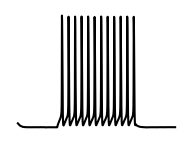

In [ ]:
with use_style("pyloric"):
    fig = plt.figure(figsize=(2,1.5))
    plt.plot(V, color="black")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    fig.savefig("true_trace.svg")

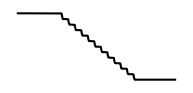

In [ ]:
with use_style("pyloric"):
    fig = plt.figure(figsize=(2,1.))
    plt.plot(energy, color="black")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    fig.savefig("true_energy.svg")

In [ ]:
energy_true

Array([-3054.359], dtype=float32)

In [ ]:
x_o

Array([ 13.   , -68.613,   0.659, -52.315, 627.207,   2.578,   8.59 ],      dtype=float32)

In [8]:
model = load_model("bm_hh2", 0)

In [9]:
samples_only_spike_count = model.sample(10000, x_o = x_o[:1], condition_mask=jnp.array([False]*7 +[True] + [False]*6 + [False]), rng=jax.random.PRNGKey(0))

Sampling method:  sde


In [10]:
samples_only_spike_count_and_resting_stats = model.sample(10000, x_o = x_o[:3], condition_mask=jnp.array([False]*7 +[True]*3 + [False]*4 + [False]), rng=jax.random.PRNGKey(0))

Sampling method:  sde


In [11]:
samples_all_stats = model.sample(10000, x_o = x_o, condition_mask=jnp.array([False]*7 +[True]*7 + [False]), rng=jax.random.PRNGKey(42))

Sampling method:  sde


In [ ]:
with use_style("pyloric"):
    fig, axes = marginal_plot([np.array(samples_only_spike_count[:, :]),np.array(samples_only_spike_count_and_resting_stats[:, :7]), np.array(samples_all_stats[:, :7])], points= np.array([theta_true]), limits=limits,figsize=(7,1.5), labels=labels, bins=50, alpha=0.5, points_colors=["black"])
    for i in range(7):
        axes[0,i].set_xticks(limits[i])

    plt.legend(["Spike count", "Spike count + $V_{rest}$ moments", "Spike count + $V_{rest}$ moments + $V_{spike}$ moments "], ncols=3, loc = "upper center", bbox_to_anchor=(-3., 1.5), frameon=False)
    plt.tight_layout()
    plt.show()
    fig.savefig("bm_hh_marginal.svg", bbox_inches="tight")

NameError: name 'samples_only_spike_count' is not defined

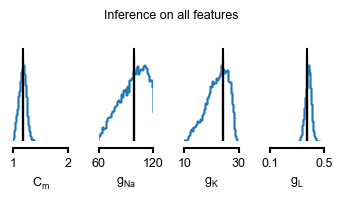

In [ ]:
with use_style("pyloric"):
    fig, axes = marginal_plot([np.array(samples_all_stats[:, :4])], points= np.array(theta_true[:4]), limits=limits,figsize=(3.5,2.), labels=labels, bins=50, alpha=0.5, points_colors=["black"])
    for i in range(4):
        axes[0,i].set_xticks(limits[i])
    fig.suptitle("Inference on all features")
    
    plt.tight_layout()
    plt.show()
    fig.savefig("bm_hh_marginal_all_features.svg", bbox_inches="tight")

In [49]:
with jax.default_device(jax.devices("cpu")[0]):
    simulator_energies = []
    for i in range(10):
        _,energies,stats = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(1), 1000), samples_all_stats[i*1000:(i+1)*1000, :7])
        simulator_energies.append(energies)
        
    simulator_energies = jnp.concatenate(simulator_energies, axis=0)

In [ ]:
Vs, _,summary = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(42), 3), samples_all_stats[:3, :7])

In [ ]:
#Vs, _,summary = jax.vmap(simulator, in_axes=(0, None))(jax.random.split(jax.random.PRNGKey(0), 100), theta_true)

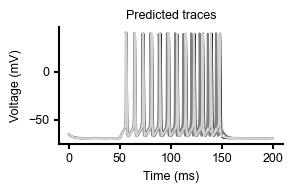

In [ ]:
with use_style("pyloric"):
    fig = plt.figure(figsize=(3,2.))
    ts = jnp.linspace(0, 200, 5000)
    plt.plot(ts,Vs[0,:], color="black")
    plt.plot(ts,Vs[1,:], color="grey")
    plt.plot(ts,Vs[2,:], color="lightgrey")
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")
    plt.title("Predicted traces")
    plt.tight_layout()
    fig.savefig("bm_hh_traces.svg", bbox_inches="tight")
    
    plt.show()

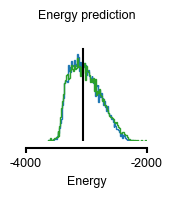

In [249]:
with use_style("pyloric"):
    fig, axes = marginal_plot([np.array(samples_all_stats[:, -1:]), np.array(simulator_energies[:,-1:])], points= np.array(energy_true),figsize=(1.8,1.95),labels=["Energy"], limits=[(-4000, -2000)],  alpha=0.5, points_colors=["black"],hist_diag={"bins":100, "density":True})
    
    axes[0,0].set_xticks([-4000, -2000])    

    fig.suptitle("Energy prediction")
    plt.tight_layout()
    fig.savefig("bm_hh_marginal_energy_all_features.svg", bbox_inches="tight")
    plt.show()

In [63]:
jnp.quantile(simulator_energies[:,-1:], 0.1), jnp.quantile(simulator_energies[:,-1:], 0.9)

(Array(-3332.318, dtype=float32), Array(-2650.02, dtype=float32))

In [52]:
condition_mask = jnp.array([False]*7 +[True]*7 + [False])
constraint_mask = jnp.array([False]*7 +[False]*7 + [True])

In [239]:
constraint_lower = model.z_score_params["z_score_fn"](  jnp.array([-2600.]),jnp.array([14], dtype=int))
constraint_upper = model.z_score_params["z_score_fn"]( jnp.array([0.]),jnp.array([14], dtype=int))

In [240]:

def exp_power_scaling(t, scaling=5., max_steepness=100, order=4):
    return jnp.exp(-t**order*scaling)*max_steepness

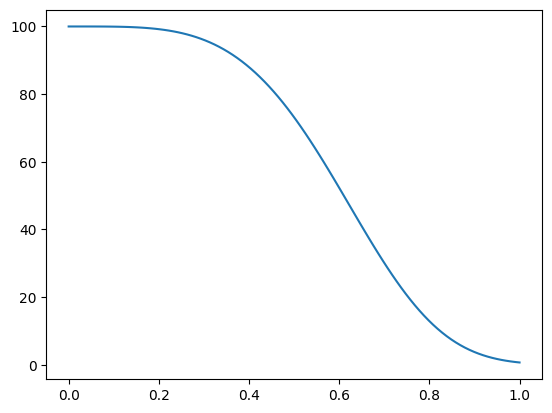

In [241]:
plt.plot(jnp.linspace(0, 1, 100), exp_power_scaling(jnp.linspace(0, 1, 100), scaling=5, max_steepness=100, order=4))
plt.show()

In [242]:

samples = model.sample(10000, x_o=x_o, condition_mask=condition_mask, rng=jax.random.PRNGKey(0),sampling_method="generalized_guidance",num_steps=1000, score_manipulator="interval", constraint_mask=constraint_mask, score_manipulator_kwargs={"a":constraint_lower, "b":constraint_upper,"scaling_fn" : exp_power_scaling})

In [243]:
with jax.default_device(jax.devices("cpu")[0]):
    simulator_energies_constrained = []
    for i in range(10):
        _,energies,stats = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(i), 1000), samples[i*1000:(i+1)*1000, :7])
        simulator_energies_constrained.append(energies)
        
    simulator_energies_constrained = jnp.concatenate(simulator_energies_constrained, axis=0)

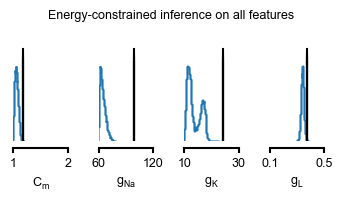

In [244]:
with use_style("pyloric"):
    fig, axes = marginal_plot([np.array(samples[:, :4])], points=[np.array(theta_true)] , limits=limits,figsize=(3.5,2.), labels=labels, bins=50, alpha=0.5, points_colors=["black"], color="C2")
    for i in range(4):
        axes[0,i].set_xticks(limits[i])

    fig.suptitle("Energy-constrained inference on all features")
    plt.tight_layout()
    plt.show()
    fig.savefig("bm_hh_marginal_energies_constrained.svg", bbox_inches="tight")

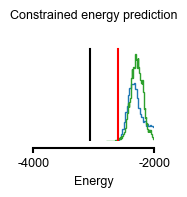

In [245]:
with use_style("pyloric"):
    fig, axes = marginal_plot([np.array(samples[:, -1:]), np.array(simulator_energies_constrained[:,-1:])], points= [np.array(jnp.array([-2600.])), np.array(energy_true)],figsize=(1.8,1.95),labels=["Energy"], limits=[(-4000, -2000)], bins=100, alpha=0.5, points_colors=["red", "black"],  hist_diag={"bins":100, "density":True})
    axes[0,0].set_xticks([-4000, -2000])
    fig.suptitle("Constrained energy prediction")
    plt.tight_layout()
    fig.savefig("bm_hh_marginal_energy_constraint.svg", bbox_inches="tight")
    plt.show()

In [246]:
Vs, _,summary = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(42), 3), samples[:3, :7])

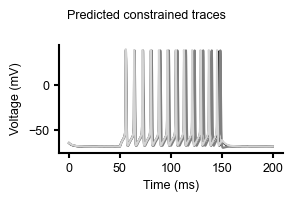

In [247]:
with use_style("pyloric"):
    fig = plt.figure(figsize=(3,2.))
    ts = jnp.linspace(0, 200, 5000)
    plt.plot(ts,Vs[0,:], color="black")
    plt.plot(ts,Vs[1,:], color="grey")
    plt.plot(ts,Vs[2,:], color="lightgrey")
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")
    fig.suptitle("Predicted constrained traces")
    plt.tight_layout()
    fig.savefig("bm_hh_traces_energy_constrained.svg", bbox_inches="tight")
    
    plt.show()

In [248]:
summary

Array([[ 12.   , -68.552,   0.653, -52.151, 629.771,   2.503,   8.248],
       [ 12.   , -68.606,   0.662, -51.49 , 667.552,   2.422,   7.785],
       [ 12.   , -68.523,   0.694, -52.144, 635.439,   2.521,   8.344]],      dtype=float32)

In [ ]:
# # with jax.default_defa
# simulator_energies = []
# for i in range(10):
#     _,energies,stats = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), 1000), samples[:1000, :7])
#     simulator_energies.append(energies)
    
# simulator_energies = jnp.concatenate(simulator_energies, axis=0)

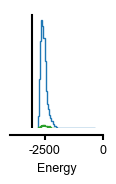

In [ ]:
with use_style("pyloric"):
    fig, axes = marginal_plot([np.array(samples[:, -1:]), np.array(simulator_energies)], points= np.array(energy_true),figsize=(1.2,1.5),labels=["Energy"], limits=[(-4000, 10)], bins=100, alpha=0.5, points_colors=["black"])

    fig.savefig("bm_hh_marginal_energy_constraint.svg", bbox_inches="tight")
    plt.show()

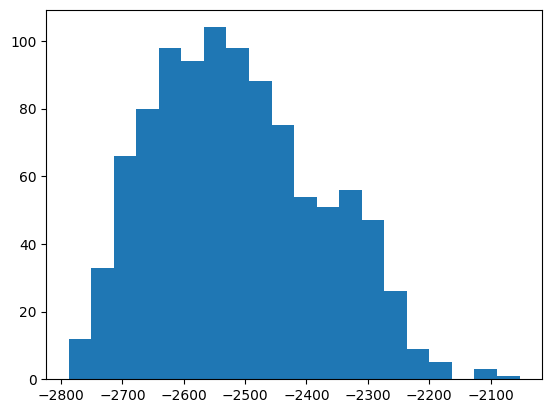

In [ ]:
_ = plt.hist(energies.flatten(), bins=20)

In [ ]:
pairplot(np.array(samples[:, :7]), points= np.array([dataset["theta"][1]]))

(<Figure size 1000x1000 with 49 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 5'>,
         <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: xlabel='dim 6'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: xlabel='dim 7'>]], dtype=object))

(array([  8., 103., 251., 459., 580., 698., 818., 798., 798., 789., 740.,
        686., 595., 508., 463., 325., 236., 209., 153., 170., 122.,  98.,
         85.,  79.,  57.,  46.,  35.,  26.,  20.,  13.,  12.,   6.,   7.,
          1.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([-2833.123, -2808.105, -2783.086, -2758.067, -2733.049, -2708.03 ,
        -2683.011, -2657.993, -2632.974, -2607.955, -2582.937, -2557.918,
        -2532.899, -2507.881, -2482.862, -2457.843, -2432.825, -2407.806,
        -2382.787, -2357.769, -2332.75 , -2307.731, -2282.713, -2257.694,
        -2232.675, -22

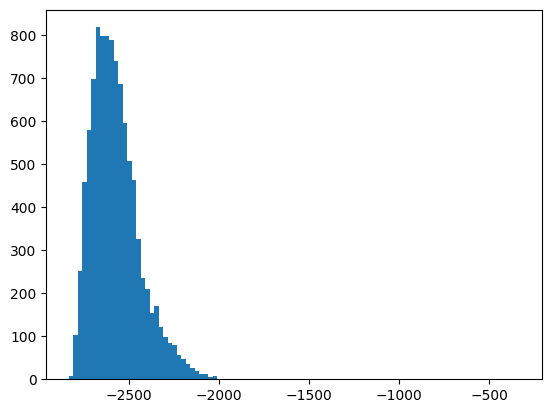

In [ ]:
plt.hist(samples[:, 8].flatten(), bins=100)

In [ ]:
keys = jax.random.split(jax.random.PRNGKey(0), 100)
Vs, energy, summary_stats = jax.vmap(simulator)(keys, samples_only_spike_count[:100, :7])

In [ ]:
?marginal_plot

Signature:
marginal_plot(
    samples: Union[List[numpy.ndarray], List[torch.Tensor], numpy.ndarray, torch.Tensor],
    points: Union[List[numpy.ndarray], List[torch.Tensor], numpy.ndarray, torch.Tensor, NoneType] = None,
    limits: Union[List, torch.Tensor, NoneType] = None,
    subset: Optional[List[int]] = None,
    diag: Optional[str] = 'hist',
    figsize: Tuple = (10, 10),
    labels: Optional[List[str]] = None,
    ticks: Union[List, torch.Tensor] = [],
    fig=None,
    axes=None,
    **kwargs,
)
Docstring:
Plot samples in a row showing 1D marginals of selected dimensions.

Each of the plots can be interpreted as a 1D-marginal of the distribution
that the samples were drawn from.

Args:
    samples: Samples used to build the histogram.
    points: List of additional points to scatter.
    limits: Array containing the plot xlim for each parameter dimension. If None,
        just use the min and max of the passed samples
    subset: List containing the dimensions to plot. E.g. s

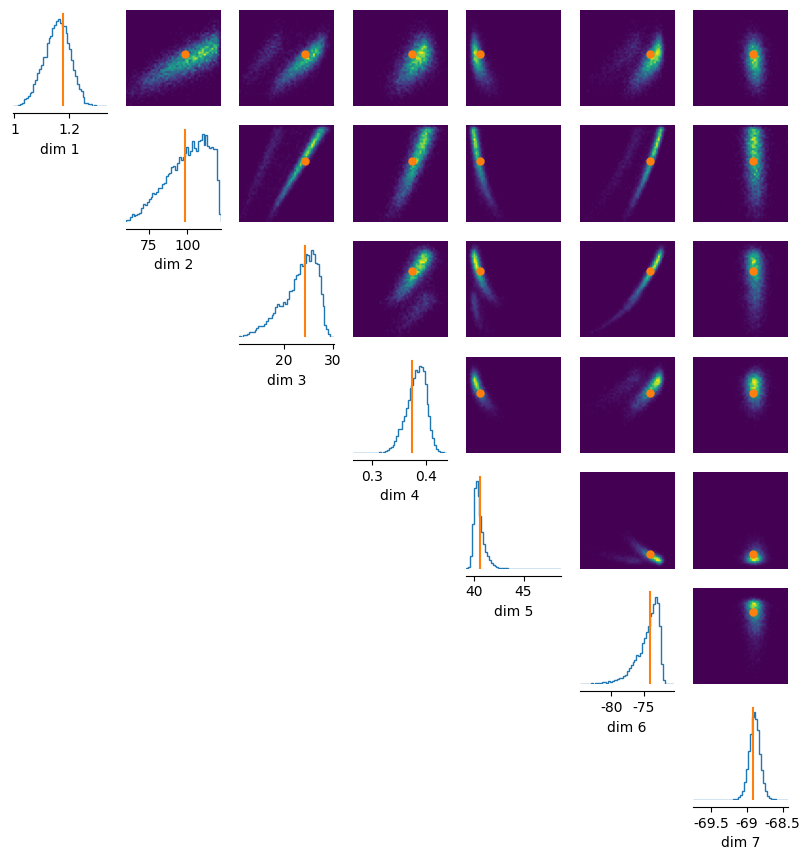

In [ ]:


pairplot(np.array(samples_all_stats[:, :7]), points= np.array([dataset["theta"][1]]))
plt.show()

# with use_style("pyloric"):
#     fig, axes = marginal_plot(np.array(samples[:, :7]), points= np.array([dataset["theta"][16]]), limits=limits,figsize=(7,2))
#     plt.tight_layout()
#     plt.show()

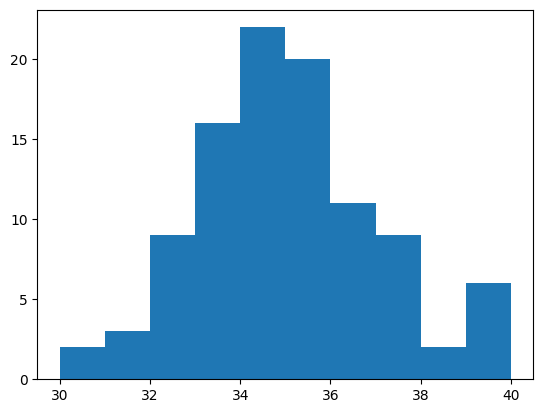

In [ ]:
_ = plt.hist(jnp.round(samples[:, 0]))